# PRISMA 2020 flow diagram

Source notebook for figure 1

PTCy meta-analysis collaboration

Figure 1 is built with the [PRISMA2020](https://github.com/prisma-flowdiagram/PRISMA2020) package, which draws the canonical PRISMA 2020 flow diagram from a counts file. The earlier version of this figure was a hand-drawn Mermaid flowchart and did not follow the standard layout.

All counts live in `data/prisma_flow.csv`, which is the package’s own template with the `n` column filled in. To correct a number, edit that file and re-render — nothing here hard-codes a count.

In [ ]:
library(PRISMA2020)
library(readr)
library(dplyr)



Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

## The counts

In [ ]:
flow |>
  filter(!is.na(n), n != "", n != "0") |>
  select(Field = data, Count = n) |>
  kable()


  -------------------------------------------------------------------------------------------
  Field                       Count
  --------------------------- ---------------------------------------------------------------
  database_results            4145

  database_specific_results   EMBASE, 2603; PubMed, 1061; SCOPUS, 481

  duplicates                  1220

  records_screened            2925

  records_excluded            2408

  dbr_sought_reports          517

  dbr_notretrieved_reports    52

  dbr_assessed                465

  dbr_excluded                Conference abstract, 116; Single-arm or no PTCy contrast, 41;
                              Review (not primary study), 21; Duplicate publication, 13;
                              Systematic review or meta-analysis, 11; Non-eligible
                              population, 5; Protocol or survey only, 4; Other, 3

  new_studies                 251

  total_studies               251

  total_studies_ma            117
  -------------------------------------------------------------------------------------------


### Arithmetic check

The flow only makes sense if each stage reconciles. This fails the render if it does not, so the figure cannot silently drift out of step with the Results text.

In [ ]:
# The template's `data` column is NA on the title-box rows, so `flow$data == key`
# would return NA padding alongside the match. Match on identity instead.
field <- function(key) {
  v <- flow$n[which(flow$data == key)]
  stopifnot(length(v) == 1)
  v
}
n <- function(key) as.numeric(field(key))

identified <- n("database_results")
dupes      <- n("duplicates")
screened   <- n("records_screened")
excl_ta    <- n("records_excluded")
sought     <- n("dbr_sought_reports")
notret     <- n("dbr_notretrieved_reports")
assessed   <- n("dbr_assessed")
included   <- n("new_studies")

# "Reason, n; Reason, n; ..." -> the numbers
reasons  <- strsplit(field("dbr_excluded"), ";")[[1]]
excl_ft  <- sum(as.numeric(sub("^.*,\\s*", "", reasons)))

# per-database counts must add up to the database total
dbs      <- strsplit(field("database_specific_results"), ";")[[1]]
db_total <- sum(as.numeric(sub("^.*,\\s*", "", dbs)))

checks <- tibble::tribble(
  ~step,                                   ~lhs,                  ~rhs,
  "per-database counts = total",            db_total,              identified,
  "identified - duplicates = screened",     identified - dupes,    screened,
  "screened - excluded = sought",           screened - excl_ta,    sought,
  "sought - not retrieved = assessed",      sought - notret,       assessed,
  "assessed - excluded = included",         assessed - excl_ft,    included
) |> mutate(ok = lhs == rhs)

print(as.data.frame(checks))


                                step  lhs  rhs   ok
1        per-database counts = total 4145 4145 TRUE
2 identified - duplicates = screened 2925 2925 TRUE
3       screened - excluded = sought  517  517 TRUE
4  sought - not retrieved = assessed  465  465 TRUE
5     assessed - excluded = included  251  251 TRUE


all stages reconcile; full-text exclusion reasons sum to 214

## The diagram

`previous = FALSE` because there is no earlier version of this review, and `other = FALSE` because although reference lists and citation tracking were searched (appendix p 2), those yields were not recorded separately and so cannot be shown as a second identification column.

In [ ]:
plot <- PRISMA_flowdiagram(
  PRISMA_data(as.data.frame(flow)),
  interactive       = FALSE,
  previous          = FALSE,   # no previous version of this review
  other             = FALSE,   # other-methods yields not separately recorded
  detail_databases  = TRUE,    # show the EMBASE / PubMed / SCOPUS split
  meta_analysis     = TRUE,    # show the 117 studies carried into the models
  side_boxes        = TRUE,
  fontsize          = 10,
  font              = "Helvetica"
)


Warning in PRISMA_flowdiagram(PRISMA_data(as.data.frame(flow)), interactive =
FALSE, : 3

### Journal colours

The package writes its colour arguments straight into the Graphviz source unquoted, so a hex value such as `#B20D35` is a DOT syntax error and only X11 colour names get through. The diagram is therefore built with the defaults and recoloured afterwards, by rewriting those names in the DOT with quoted hex.

In [ ]:
lancet_red   <- "#B20D35"   # sampled from the journal's own PDF
lancet_tint  <- "#F7DFDF"
lancet_dark  <- "#2D2D2D"

dot <- plot$x$diagram

# The title bar and the Identification / Screening / Included rails.
dot <- gsub("Goldenrod1",      sprintf('"%s"', lancet_red),  dot, fixed = TRUE)
dot <- gsub("LightSteelBlue2", sprintf('"%s"', lancet_tint), dot, fixed = TRUE)

# White text on the crimson bar. This has to go on the title node itself, not on
# the `node [...]` defaults block above it -- a fontcolor set there cascades to
# every node declared afterwards and turns the whole diagram's text white.
# `style = "rounded,filled"` is unique to the title bar; the rails use
# `"filled,rounded"`, the other order.
stopifnot(sum(gregexpr('style = "rounded,filled"', dot, fixed = TRUE)[[1]] > 0) == 1)
dot <- sub('style = "rounded,filled"',
           'style = "rounded,filled", fontcolor = "white"', dot, fixed = TRUE)

stopifnot(!grepl("Goldenrod1|LightSteelBlue2", dot))
plot$x$diagram <- dot


In [ ]:
# PRISMA_save writes one file per call and infers nothing from the extension.
for (ft in c("PNG", "PDF", "SVG")) {
  PRISMA_save(
    plot,
    filename  = here("figures", paste0("Figure1_PRISMA_flow_diagram.", tolower(ft))),
    filetype  = ft,
    overwrite = TRUE
  )
}


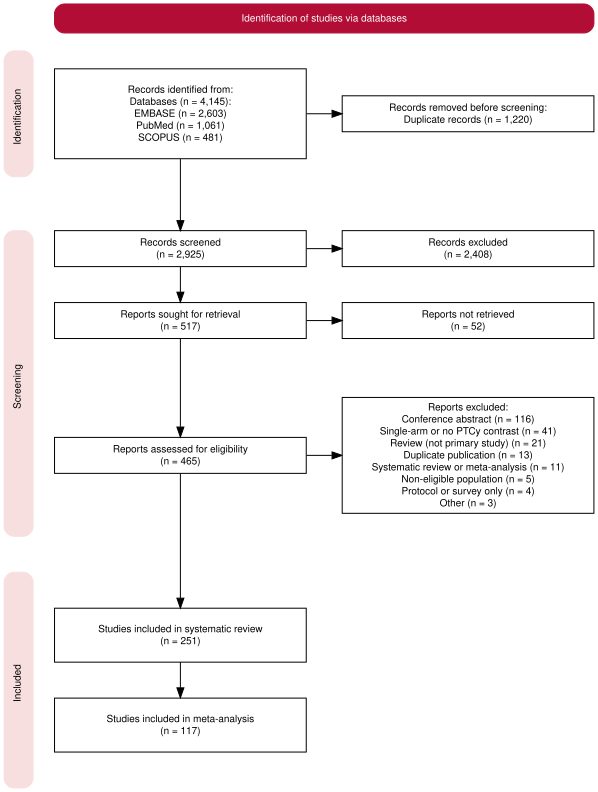

In [ ]:
knitr::include_graphics(here("figures", "Figure1_PRISMA_flow_diagram.png"))


## Reproducing this

`PRISMA2020` pulls in `DiagrammeRsvg`, which needs `V8`, which needs a libv8 the distribution may not package. If `install.packages("V8")` fails at the configure step, use the package’s own fallback, which downloads a static build and needs no root:

``` r
Sys.setenv(DOWNLOAD_STATIC_LIBV8 = 1)
install.packages("V8")
install.packages("PRISMA2020")
```